## D5

MET function needs to be fixed potentially. I tried something new by fetching the data but I trust my other NOAA function more that uses downloaded files. That function exists in the data corrections notebook in the repo.

In [174]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

In [177]:
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR03_260308201320_FS029.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR04_260308201401_FS064.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu632743brackish_2026-01-11_13-47-47-563.csv"

"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/ABBYROAD_D5retrieval41.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/BALLPARK_D5retrieval46.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/BARGE_D5retrieval45.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/EYECLINIC_D5retrieval21.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/HECKARD_D5retrieval38.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/RIVERDALE_D5retrieval44.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/VET_D5retrieval33.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WATERSTREET_D5retrieval42.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu632743brackish_2026-01-11_13-47-47-563.csv"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_InSitu642743brackishJan11dep_2026-03-08_13-08-58-922.txt"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR06_RED_030826.txt"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SF01_260308202720_FS041.CSV"
"/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SF03_SashaAlexFieldDayHOBO_030826.csv"

'/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/SF03_SashaAlexFieldDayHOBO_030826.csv'

**MET DATA**

In [182]:
def fetch_noaa_met_data(start_dt, end_dt, station_id="9440910"):
    start_dt = pd.to_datetime(start_dt).tz_localize(None) 
    end_dt   = pd.to_datetime(end_dt).tz_localize(None)

    fetch_start = start_dt - pd.Timedelta(hours=3)
    fetch_end   = end_dt   + pd.Timedelta(hours=3)

    chunk_size = pd.Timedelta(days=31)
    chunks, chunk_start = [], fetch_start
    while chunk_start < fetch_end:
        chunk_end = min(chunk_start + chunk_size, fetch_end)
        chunks.append((chunk_start, chunk_end))
        chunk_start = chunk_end

    print(f"Fetching {len(chunks)} chunk(s) from NOAA CO-OPS...")
    all_frames = []
    for i, (cs, ce) in enumerate(chunks):
        params = {
            "begin_date":  cs.strftime("%Y%m%d %H:%M"),
            "end_date":    ce.strftime("%Y%m%d %H:%M"),
            "station":     station_id,
            "product":     "air_pressure",
            "time_zone":   "lst", 
            "units":       "metric",
            "format":      "json",
            "application": "your_project_name",
        }
        response = requests.get("https://api.tidesandcurrents.noaa.gov/api/prod/datagetter", params=params)
        response.raise_for_status()
        payload = response.json()

        if "error" in payload:
            raise ValueError(f"NOAA API error on chunk {i+1} ({cs.date()} to {ce.date()}): {payload['error']['message']}")
        if "data" not in payload or not payload["data"]:
            print(f"  Chunk {i+1}/{len(chunks)}: no data returned ({cs.date()} → {ce.date()}), skipping.")
            continue

        chunk_df = pd.DataFrame(payload["data"])
        chunk_df["Datetime"] = pd.to_datetime(chunk_df["t"], errors="coerce")
        chunk_df = chunk_df.dropna(subset=["Datetime"]).set_index("Datetime").sort_index()
        chunk_df["Baro (Pa)"] = pd.to_numeric(chunk_df["v"], errors="coerce") * 100
        all_frames.append(chunk_df["Baro (Pa)"])
        print(f"  Chunk {i+1}/{len(chunks)}: {cs.date()} → {ce.date()} ({len(chunk_df)} records)")

    if not all_frames:
        raise ValueError("No data returned from NOAA for any chunk.")

    met_series = pd.concat(all_frames)
    met_series = met_series[~met_series.index.duplicated(keep="first")].sort_index()
    return met_series.resample("5min").interpolate(method="linear")

In [184]:
def itp_noaa_metdata(met_5min_series, sensor_dt_array):
    sensor_dt = pd.DatetimeIndex(sensor_dt_array)
    all_times = met_5min_series.index.union(sensor_dt).unique().sort_values()
    combo = met_5min_series.reindex(all_times).interpolate(method="linear")
    return combo.loc[sensor_dt]

**HANDLE DENSITY + FTH2O**

In [187]:
# Take ftH2O array and create TWL [m] 

def density(T, S):
    """
    input: temperature array in deg celsius, constant salinity value in PSU
    output: density in kg/m^3
    """
    rho_fw = 1000 * (1 - ((T + 288.9414)/(508929.2*(T + 68.12963))) * (T - 3.9863)**2)
    rho_ew = rho_fw + (0.824 * S)
    return rho_ew

def ftH2O_to_Pa(pressure_ftH2O, temperature, salinity):
    """
    Convert pressure from ftH2O to Pascals, accounting for temperature and salinity.
    
    INPUTS
    pressure_ftH2O : (array) pressure readings in feet of water (ftH2O)
    temperature : (array) temperature readings in degrees Celsius
    salinity : constant salinity value in PSU
    
    OUTPUTS
    pressure_Pa : array-like
        Pressure in Pascals
    """
    # Constants
    g = 9.81  # gravitational acceleration (m/s²)
    ft_to_m = 0.3048  # feet to meters conversion
    
    # Calculate density based on temperature and salinity
    rho = density(temperature, salinity)
    
    # Convert ftH2O to meters of water, then to Pascals
    # P = ρ * g * h
    pressure_Pa = rho * g * (pressure_ftH2O * ft_to_m)
    
    return pressure_Pa

## RAPID SENSORS

In [190]:
abbyroad_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/ABBYROAD_D5retrieval41.CSV"
ballpark_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/BALLPARK_D5retrieval46.CSV"
barge_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/BARGE_D5retrieval45.CSV"
eyeclinic_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/EYECLINIC_D5retrieval21.CSV"
heckard_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/HECKARD_D5retrieval38.CSV"
riverdale_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/RIVERDALE_D5retrieval44.CSV"
vet_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/VET_D5retrieval33.CSV"
waterstreet_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WATERSTREET_D5retrieval42.CSV";

**Abby Road**

In [193]:
abbyroad_df = pd.read_csv(abbyroad_file)
abbyroad_serial_num = 41 # INSIDE SAYS 42 BUT THATS WATERSTREET...
abbyroad_navd88_offset = 4.441 # meters
abbyroad_df.head()

,W.G. Num: 42,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC]
0,2025/12/10,13:34:42:131,999.4,24.04,4.33
1,2025/12/10,13:36:43:033,999.5,24.04,4.13
2,2025/12/10,13:38:43:031,999.5,24.03,4.13
3,2025/12/10,13:40:43:031,999.6,24.00,4.13
4,2025/12/10,13:42:43:030,999.5,23.98,4.13


In [195]:
abbyroad_df["Datetime[PST]"] = pd.to_datetime(
    abbyroad_df["W.G. Num: 42"].astype(str) + " " + abbyroad_df["Timestamp"].astype(str),
    format="%Y/%m/%d %H:%M:%S:%f", errors="coerce") 

abbyroad_start = abbyroad_df["Datetime[PST]"].dropna().iloc[0]
abbyroad_end   = abbyroad_df["Datetime[PST]"].dropna().iloc[-1]
abbyroad_met_df_5min = fetch_noaa_met_data(abbyroad_start, abbyroad_end)

abbyroad_df["MetPressure[Pa]"] = itp_noaa_metdata(abbyroad_met_df_5min, abbyroad_df["Datetime[PST]"]).values

g = 9.81
salinity = 0.5
abbyroad_df["Rho[kg/m^3]"]    = density(abbyroad_df["Temp [deg C]"], salinity)
abbyroad_df["AbsPressure[Pa]"] = abbyroad_df["Pressure [mbar]"] * 100
abbyroad_df["TWL[m]"]          = (abbyroad_df["AbsPressure[Pa]"] - abbyroad_df["MetPressure[Pa]"]) / (abbyroad_df["Rho[kg/m^3]"] * g)
abbyroad_df["TWLNAVD88[m]"]    = abbyroad_df["TWL[m]"] + abbyroad_navd88_offset

abbyroad_dt = abbyroad_df["Datetime[PST]"]
abbyroad_twl = abbyroad_df["TWLNAVD88[m]"]

abbyroad_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6476 records)


,W.G. Num: 42,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:34:42:131,999.4,24.04,4.33,2025-12-10 13:34:42.131,101599.166667,997.728743,99940.0,-0.169515,4.271485
1,2025/12/10,13:36:43:033,999.5,24.04,4.13,2025-12-10 13:36:43.033,101597.777778,997.728743,99950.0,-0.168352,4.272648
2,2025/12/10,13:38:43:031,999.5,24.03,4.13,2025-12-10 13:38:43.031,101597.222222,997.731213,99950.0,-0.168294,4.272706
3,2025/12/10,13:40:43:031,999.6,24.00,4.13,2025-12-10 13:40:43.031,101596.250000,997.738618,99960.0,-0.167172,4.273828
4,2025/12/10,13:42:43:030,999.5,23.98,4.13,2025-12-10 13:42:43.030,101595.833333,997.743549,99950.0,-0.168150,4.272850


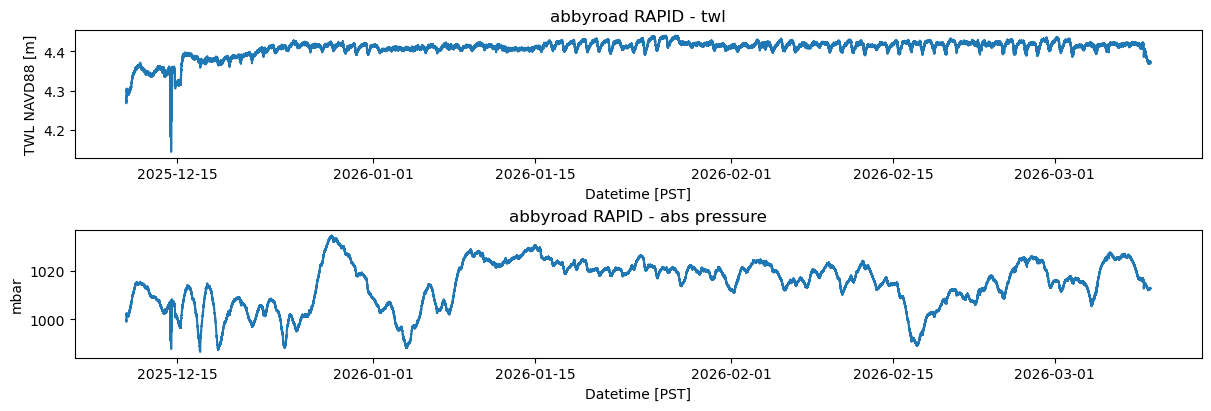

In [303]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(abbyroad_dt, abbyroad_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("abbyroad RAPID - twl")

ax[1].plot(abbyroad_dt, abbyroad_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("abbyroad RAPID - abs pressure");

**Ballpark**

In [200]:
ballpark_df = pd.read_csv(ballpark_file)
ballpark_serial_num = 46
ballpark_navd88_offset = 3.651 # meters REVISIT THIS OFFSET
ballpark_df.head()

,W.G. Num: 46,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC]
0,2025/12/10,13:33:28:133,998.6,23.66,4.27
1,2025/12/10,13:35:29:031,998.4,23.67,4.13
2,2025/12/10,13:37:29:031,998.6,23.69,4.13
3,2025/12/10,13:39:29:031,998.8,23.71,4.13
4,2025/12/10,13:41:29:031,998.3,23.72,4.13


In [202]:
ballpark_df["Datetime[PST]"] = pd.to_datetime(ballpark_df["W.G. Num: 46"].astype(str) + " " + ballpark_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")
ballpark_start = ballpark_df["Datetime[PST]"].dropna().iloc[0]
ballpark_end   = ballpark_df["Datetime[PST]"].dropna().iloc[-1]
ballpark_met_df_5min = fetch_noaa_met_data(ballpark_start, ballpark_end)
ballpark_df["MetPressure[Pa]"] = itp_noaa_metdata(ballpark_met_df_5min, ballpark_df["Datetime[PST]"]).values

g = 9.81
salinity = 0.5

ballpark_df["Rho[kg/m^3]"]    = density(ballpark_df["Temp [deg C]"], salinity)
ballpark_df["AbsPressure[Pa]"] = ballpark_df["Pressure [mbar]"] * 100
ballpark_df["TWL[m]"]          = (ballpark_df["AbsPressure[Pa]"] - ballpark_df["MetPressure[Pa]"]) / (ballpark_df["Rho[kg/m^3]"] * g)
ballpark_df["TWLNAVD88[m]"]    = ballpark_df["TWL[m]"] + ballpark_navd88_offset

ballpark_dt  = ballpark_df["Datetime[PST]"]
ballpark_twl = ballpark_df["TWLNAVD88[m]"]

ballpark_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6475 records)


,W.G. Num: 46,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:33:28:133,998.6,23.66,4.27,2025-12-10 13:33:28.133,101599.166667,997.821927,99860.0,-0.177672,3.473328
1,2025/12/10,13:35:29:031,998.4,23.67,4.13,2025-12-10 13:35:29.031,101597.916667,997.819493,99840.0,-0.179588,3.471412
2,2025/12/10,13:37:29:031,998.6,23.69,4.13,2025-12-10 13:37:29.031,101597.500000,997.814621,99860.0,-0.177503,3.473497
3,2025/12/10,13:39:29:031,998.8,23.71,4.13,2025-12-10 13:39:29.031,101597.083333,997.809746,99880.0,-0.175418,3.475582
4,2025/12/10,13:41:29:031,998.3,23.72,4.13,2025-12-10 13:41:29.031,101596.111111,997.807307,99830.0,-0.180427,3.470573


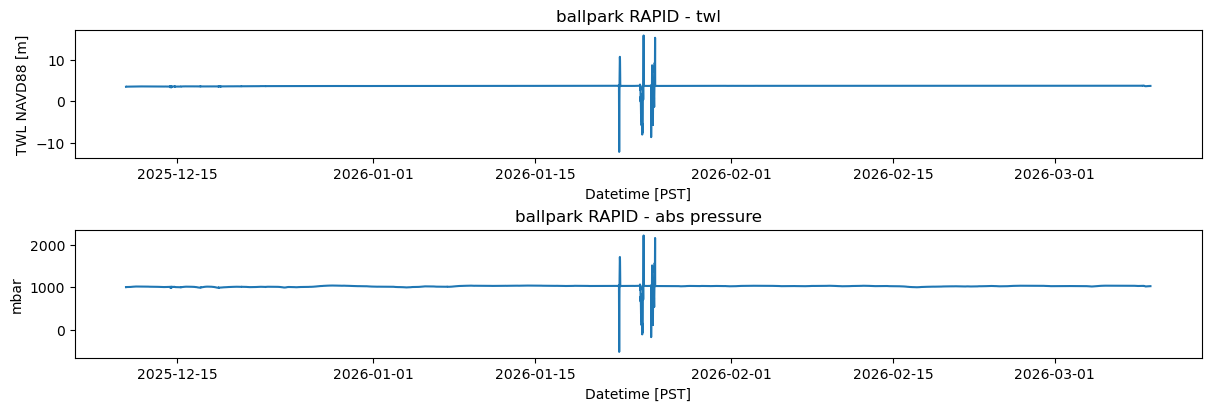

In [301]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(ballpark_dt, ballpark_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("ballpark RAPID - twl")

ax[1].plot(ballpark_dt, ballpark_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("ballpark RAPID - abs pressure");

**Barge Restaurant**

In [205]:
barge_df = pd.read_csv(barge_file)
barge_serial_num = 45
barge_navd88_offset = 3.532 # meters
barge_df.head()

,W.G. Num: 45,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC]
0,2025/12/10,13:30:02:133,997.6,23.71,4.36
1,2025/12/10,13:32:03:031,997.6,23.72,4.18
2,2025/12/10,13:34:03:031,997.7,23.73,4.18
3,2025/12/10,13:36:03:031,997.5,23.75,4.18
4,2025/12/10,13:38:03:031,997.5,23.76,4.18


In [209]:
barge_df["Datetime[PST]"] = pd.to_datetime(barge_df["W.G. Num: 45"].astype(str) + " " + barge_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")
barge_start = barge_df["Datetime[PST]"].dropna().iloc[0]
barge_end   = barge_df["Datetime[PST]"].dropna().iloc[-1]
barge_met_df_5min = fetch_noaa_met_data(barge_start, barge_end)
barge_df["MetPressure[Pa]"] = itp_noaa_metdata(barge_met_df_5min, barge_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
barge_df["Rho[kg/m^3]"]    = density(barge_df["Temp [deg C]"], salinity)
barge_df["AbsPressure[Pa]"] = barge_df["Pressure [mbar]"] * 100
barge_df["TWL[m]"]          = (barge_df["AbsPressure[Pa]"] - barge_df["MetPressure[Pa]"]) / (barge_df["Rho[kg/m^3]"] * g)
barge_df["TWLNAVD88[m]"]    = barge_df["TWL[m]"] + barge_navd88_offset
barge_dt  = barge_df["Datetime[PST]"]
barge_twl = barge_df["TWLNAVD88[m]"]
barge_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7441 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7441 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6477 records)


,W.G. Num: 45,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:30:02:133,997.6,23.71,4.36,2025-12-10 13:30:02.133,101599.583333,997.809746,99760.0,-0.187933,3.344067
1,2025/12/10,13:32:03:031,997.6,23.72,4.18,2025-12-10 13:32:03.031,101599.166667,997.807307,99760.0,-0.187891,3.344109
2,2025/12/10,13:34:03:031,997.7,23.73,4.18,2025-12-10 13:34:03.031,101598.750000,997.804867,99770.0,-0.186827,3.345173
3,2025/12/10,13:36:03:031,997.5,23.75,4.18,2025-12-10 13:36:03.031,101597.777778,997.799984,99750.0,-0.188772,3.343228
4,2025/12/10,13:38:03:031,997.5,23.76,4.18,2025-12-10 13:38:03.031,101597.222222,997.797541,99750.0,-0.188716,3.343284


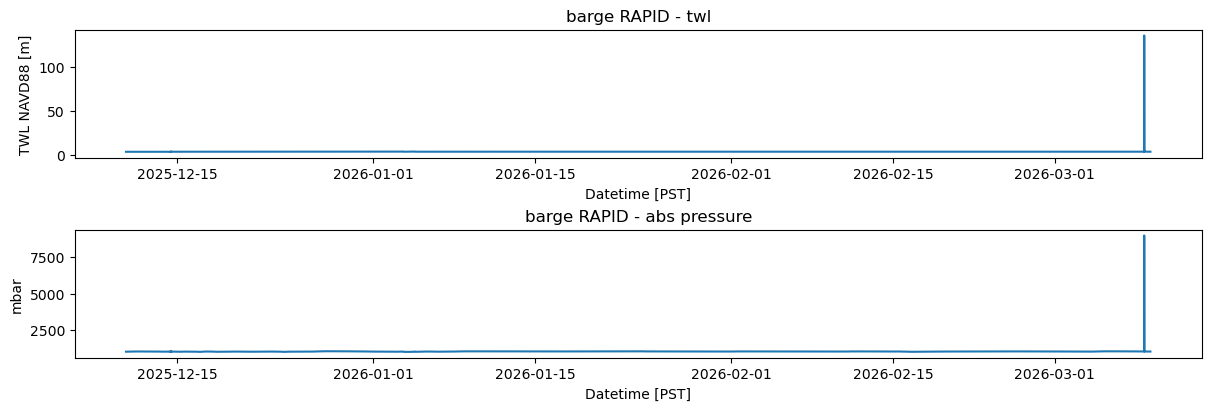

In [299]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(barge_dt, barge_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("barge RAPID - twl")


ax[1].plot(barge_dt, barge_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("barge RAPID - abs pressure");

**Eye Clinic**

In [307]:
eyeclinic_df = pd.read_csv(eyeclinic_file)
eyeclinic_serial_num = 21
eyeclinic_navd88_offset = 0 #3.785 # meters
eyeclinic_df.head()

,W.G. Num: 21,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC]
0,2025/12/10,13:32:01:131,999.9,23.64,4.22
1,2025/12/10,13:34:02:031,1000.2,23.65,4.14
2,2025/12/10,13:36:02:031,999.8,23.67,4.14
3,2025/12/10,13:38:02:030,999.8,23.68,4.14
4,2025/12/10,13:40:02:030,999.9,23.69,4.14


In [309]:
eyeclinic_df["Datetime[PST]"] = pd.to_datetime(eyeclinic_df["W.G. Num: 21"].astype(str) + " " + eyeclinic_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")
eyeclinic_start = eyeclinic_df["Datetime[PST]"].dropna().iloc[0]
eyeclinic_end   = eyeclinic_df["Datetime[PST]"].dropna().iloc[-1]
eyeclinic_met_df_5min = fetch_noaa_met_data(eyeclinic_start, eyeclinic_end)
eyeclinic_df["MetPressure[Pa]"] = itp_noaa_metdata(eyeclinic_met_df_5min, eyeclinic_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
eyeclinic_df["Rho[kg/m^3]"]    = density(eyeclinic_df["Temp [deg C]"], salinity)
eyeclinic_df["AbsPressure[Pa]"] = eyeclinic_df["Pressure [mbar]"] * 100
eyeclinic_df["TWL[m]"]          = (eyeclinic_df["AbsPressure[Pa]"] - eyeclinic_df["MetPressure[Pa]"]) / (eyeclinic_df["Rho[kg/m^3]"] * g)
eyeclinic_df["TWLNAVD88[m]"]    = eyeclinic_df["TWL[m]"] + eyeclinic_navd88_offset
eyeclinic_dt  = eyeclinic_df["Datetime[PST]"]
eyeclinic_twl = eyeclinic_df["TWLNAVD88[m]"]
eyeclinic_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6477 records)


,W.G. Num: 21,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:32:01:131,999.9,23.64,4.22,2025-12-10 13:32:01.131,101599.444444,997.826792,99990.0,-0.164419,-0.164419
1,2025/12/10,13:34:02:031,1000.2,23.65,4.14,2025-12-10 13:34:02.031,101598.888889,997.824360,100020.0,-0.161298,-0.161298
2,2025/12/10,13:36:02:031,999.8,23.67,4.14,2025-12-10 13:36:02.031,101597.777778,997.819493,99980.0,-0.165271,-0.165271
3,2025/12/10,13:38:02:030,999.8,23.68,4.14,2025-12-10 13:38:02.030,101597.222222,997.817058,99980.0,-0.165215,-0.165215
4,2025/12/10,13:40:02:030,999.9,23.69,4.14,2025-12-10 13:40:02.030,101596.250000,997.814621,99990.0,-0.164095,-0.164095


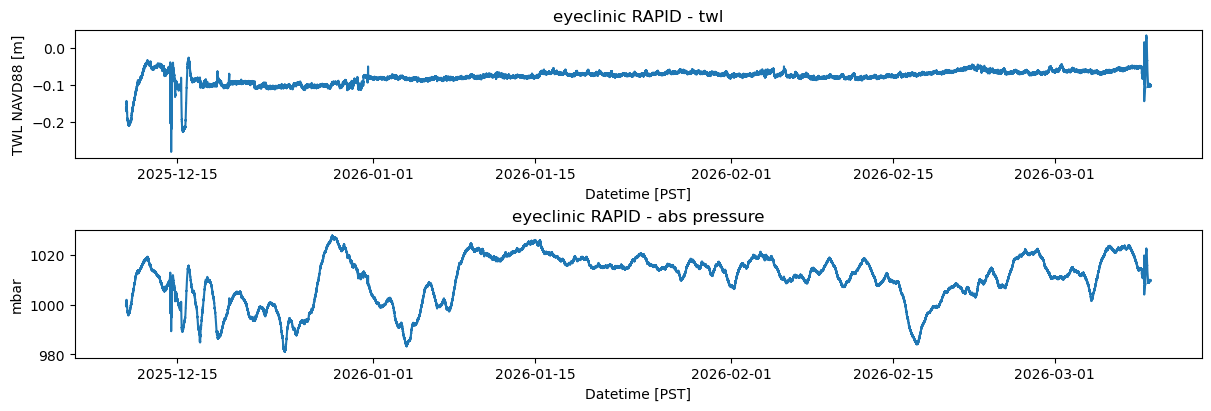

In [311]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(eyeclinic_dt, eyeclinic_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("eyeclinic RAPID - twl")

ax[1].plot(eyeclinic_dt, eyeclinic_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("eyeclinic RAPID - abs pressure");

**Heckard Road**

In [325]:
heckard_df = pd.read_csv(heckard_file)
heckard_serial_num = 38 # actually 33 in file which matches vet
heckard_navd88_offset = 0# 4.142 # meters REVISIT
heckard_df["Datetime[PST]"] = pd.to_datetime(heckard_df["W.G. Num: 33"].astype(str) + " " + heckard_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")

heckard_df.head()

,W.G. Num: 33,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST]
0,2025/12/10,13:34:06:131,1001.1,23.73,4.26,2025-12-10 13:34:06.131
1,2025/12/10,13:36:06:031,1001.1,23.79,4.17,2025-12-10 13:36:06.031
2,2025/12/10,13:38:06:031,1001.1,23.82,4.17,2025-12-10 13:38:06.031
3,2025/12/10,13:40:06:031,1001.2,23.84,4.17,2025-12-10 13:40:06.031
4,2025/12/10,13:42:06:031,1001.2,23.86,4.17,2025-12-10 13:42:06.031


In [327]:
# fig, ax = plt.subplots(figsize=(12,4))

# ax.plot(heckard_df["Datetime[PST]"][31000:33200], heckard_df["Pressure [mbar]"][31000:33200])
# # ax.plot(heckard_dt[31000:33200], heckard_twl[31000:33200])
# ax.set_xlabel("Timestamp")
# ax.set_ylabel("Pressure [mbar]")
# ax.set_title("Heckard Road uncorrected for atm p");

In [329]:
heckard_df["Datetime[PST]"] = pd.to_datetime(heckard_df["W.G. Num: 33"].astype(str) + " " + heckard_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")
heckard_start = heckard_df["Datetime[PST]"].dropna().iloc[0]
heckard_end   = heckard_df["Datetime[PST]"].dropna().iloc[-1]
heckard_met_df_5min = fetch_noaa_met_data(heckard_start, heckard_end)
heckard_df["MetPressure[Pa]"] = itp_noaa_metdata(heckard_met_df_5min, heckard_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
heckard_df["Rho[kg/m^3]"]    = density(heckard_df["Temp [deg C]"], salinity)
heckard_df["AbsPressure[Pa]"] = heckard_df["Pressure [mbar]"] * 100
heckard_df["TWL[m]"]          = (heckard_df["AbsPressure[Pa]"] - heckard_df["MetPressure[Pa]"]) / (heckard_df["Rho[kg/m^3]"] * g)
heckard_df["TWLNAVD88[m]"]    = heckard_df["TWL[m]"] + heckard_navd88_offset
heckard_dt  = heckard_df["Datetime[PST]"]
heckard_twl = heckard_df["TWLNAVD88[m]"]
heckard_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-12 (7250 records)


,W.G. Num: 33,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:34:06:131,1001.1,23.73,4.26,2025-12-10 13:34:06.131,101599.166667,997.804867,100110.0,-0.152135,-0.152135
1,2025/12/10,13:36:06:031,1001.1,23.79,4.17,2025-12-10 13:36:06.031,101597.777778,997.790206,100110.0,-0.151995,-0.151995
2,2025/12/10,13:38:06:031,1001.1,23.82,4.17,2025-12-10 13:38:06.031,101597.222222,997.782863,100110.0,-0.151940,-0.151940
3,2025/12/10,13:40:06:031,1001.2,23.84,4.17,2025-12-10 13:40:06.031,101596.250000,997.777962,100120.0,-0.150819,-0.150819
4,2025/12/10,13:42:06:031,1001.2,23.86,4.17,2025-12-10 13:42:06.031,101595.833333,997.773058,100120.0,-0.150777,-0.150777


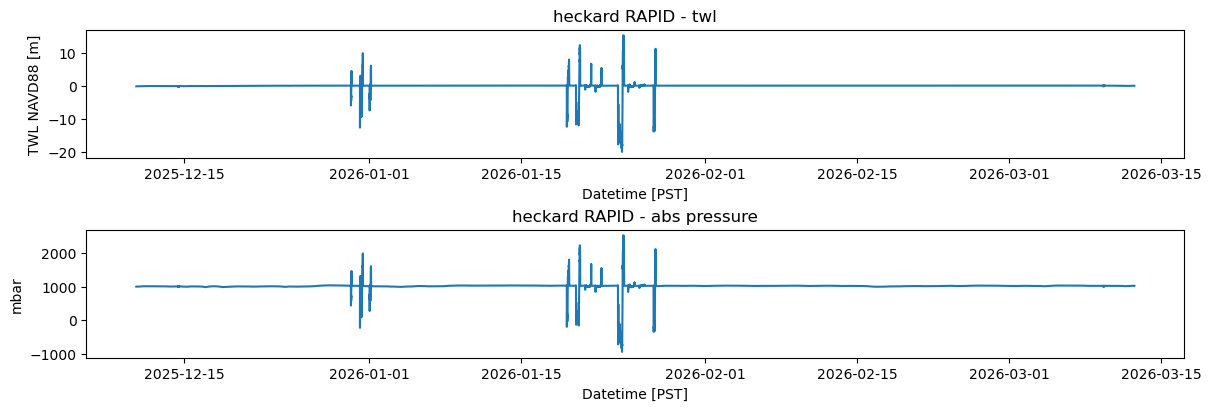

In [334]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(heckard_dt, heckard_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("heckard RAPID - twl")

ax[1].plot(heckard_dt, heckard_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("heckard RAPID - abs pressure");

In [229]:
len(heckard_dt)

66218

**Riverdale**

In [258]:
riverdale_df = pd.read_csv(riverdale_file)
riverdale_serial_num = 37 # 44 on outside
riverdale_navd88_offset = 4.49 # meters REVISIT (took earlier elev but redeployed and surveyed as float
riverdale_df["Datetime[PST]"] = pd.to_datetime(riverdale_df["W.G. Num: 37"].astype(str) + " " + riverdale_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")

riverdale_df.head()

,W.G. Num: 37,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST]
0,2025/12/10,13:29:12:133,999.0,23.71,4.30,2025-12-10 13:29:12.133
1,2025/12/10,13:31:12:032,999.1,23.73,4.13,2025-12-10 13:31:12.032
2,2025/12/10,13:33:12:030,999.2,23.75,4.13,2025-12-10 13:33:12.030
3,2025/12/10,13:35:12:030,999.3,23.77,4.13,2025-12-10 13:35:12.030
4,2025/12/10,13:37:12:031,999.0,23.78,4.13,2025-12-10 13:37:12.031


In [260]:
riverdale_start = riverdale_df["Datetime[PST]"].dropna().iloc[0]
riverdale_end   = riverdale_df["Datetime[PST]"].dropna().iloc[-1]
riverdale_met_df_5min = fetch_noaa_met_data(riverdale_start, riverdale_end)
riverdale_df["MetPressure[Pa]"] = itp_noaa_metdata(riverdale_met_df_5min, riverdale_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
riverdale_df["Rho[kg/m^3]"]    = density(riverdale_df["Temp [deg C]"], salinity)
riverdale_df["AbsPressure[Pa]"] = riverdale_df["Pressure [mbar]"] * 100
riverdale_df["TWL[m]"]          = (riverdale_df["AbsPressure[Pa]"] - riverdale_df["MetPressure[Pa]"]) / (riverdale_df["Rho[kg/m^3]"] * g)
riverdale_df["TWLNAVD88[m]"]    = riverdale_df["TWL[m]"] + riverdale_navd88_offset
riverdale_dt  = riverdale_df["Datetime[PST]"]
riverdale_twl = riverdale_df["TWLNAVD88[m]"]
riverdale_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6478 records)


,W.G. Num: 37,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:29:12:133,999.0,23.71,4.30,2025-12-10 13:29:12.133,101601.666667,997.809746,99900.0,-0.173843,4.316157
1,2025/12/10,13:31:12:032,999.1,23.73,4.13,2025-12-10 13:31:12.032,101599.444444,997.804867,99910.0,-0.172595,4.317405
2,2025/12/10,13:33:12:030,999.2,23.75,4.13,2025-12-10 13:33:12.030,101598.888889,997.799984,99920.0,-0.171518,4.318482
3,2025/12/10,13:35:12:030,999.3,23.77,4.13,2025-12-10 13:35:12.030,101597.916667,997.795097,99930.0,-0.170398,4.319602
4,2025/12/10,13:37:12:031,999.0,23.78,4.13,2025-12-10 13:37:12.031,101597.500000,997.792652,99900.0,-0.173421,4.316579


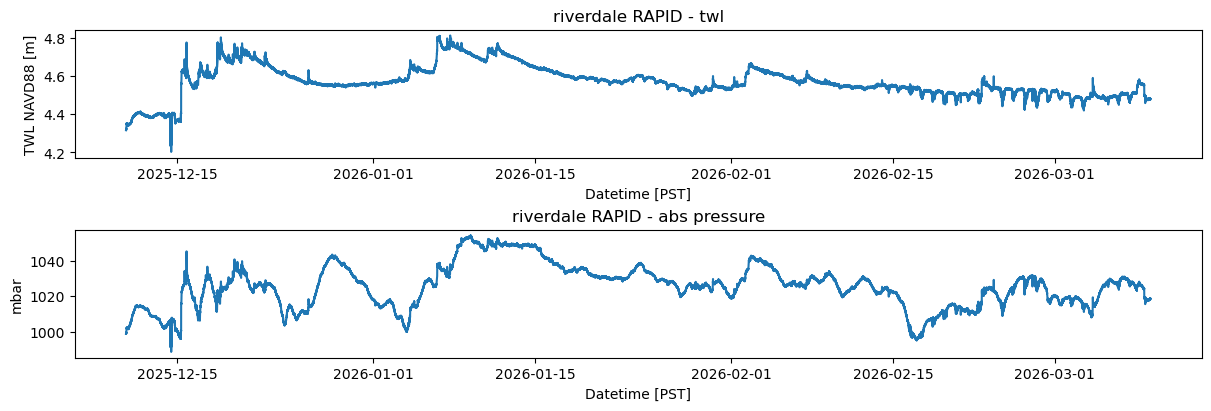

In [293]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(riverdale_dt, riverdale_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("riverdale RAPID - twl")


ax[1].plot(riverdale_dt, riverdale_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("riverdale RAPID - abs pressure");

**Vet Clinic**

In [266]:
vet_df = pd.read_csv(vet_file)
vet_serial_num = 44
vet_navd88_offset = 3.65 # meters REVISIT 
vet_df["Datetime[PST]"] = pd.to_datetime(vet_df["W.G. Num: 44"].astype(str) + " " + vet_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")

vet_df.head()

,W.G. Num: 44,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST]
0,2025/12/10,13:35:16:131,1001.8,23.91,4.23,2025-12-10 13:35:16.131
1,2025/12/10,13:37:17:030,1002.0,23.90,4.16,2025-12-10 13:37:17.030
2,2025/12/10,13:39:17:030,1002.2,23.88,4.16,2025-12-10 13:39:17.030
3,2025/12/10,13:41:17:030,1002.1,23.87,4.16,2025-12-10 13:41:17.030
4,2025/12/10,13:43:17:030,1002.0,23.85,4.16,2025-12-10 13:43:17.030


In [268]:
vet_start = vet_df["Datetime[PST]"].dropna().iloc[0]
vet_end   = vet_df["Datetime[PST]"].dropna().iloc[-1]
vet_met_df_5min = fetch_noaa_met_data(vet_start, vet_end)
vet_df["MetPressure[Pa]"] = itp_noaa_metdata(vet_met_df_5min, vet_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
vet_df["Rho[kg/m^3]"]    = density(vet_df["Temp [deg C]"], salinity)
vet_df["AbsPressure[Pa]"] = vet_df["Pressure [mbar]"] * 100
vet_df["TWL[m]"]          = (vet_df["AbsPressure[Pa]"] - vet_df["MetPressure[Pa]"]) / (vet_df["Rho[kg/m^3]"] * g)
vet_df["TWLNAVD88[m]"]    = vet_df["TWL[m]"] + vet_navd88_offset
vet_dt  = vet_df["Datetime[PST]"]
vet_twl = vet_df["TWLNAVD88[m]"]
vet_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6476 records)


,W.G. Num: 44,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:35:16:131,1001.8,23.91,4.23,2025-12-10 13:35:16.131,101597.916667,997.760779,100180.0,-0.144862,3.505138
1,2025/12/10,13:37:17:030,1002.0,23.90,4.16,2025-12-10 13:37:17.030,101597.500000,997.763237,100200.0,-0.142776,3.507224
2,2025/12/10,13:39:17:030,1002.2,23.88,4.16,2025-12-10 13:39:17.030,101597.083333,997.768149,100220.0,-0.140689,3.509311
3,2025/12/10,13:41:17:030,1002.1,23.87,4.16,2025-12-10 13:41:17.030,101596.111111,997.770604,100210.0,-0.141611,3.508389
4,2025/12/10,13:43:17:030,1002.0,23.85,4.16,2025-12-10 13:43:17.030,101595.555556,997.775510,100200.0,-0.142576,3.507424


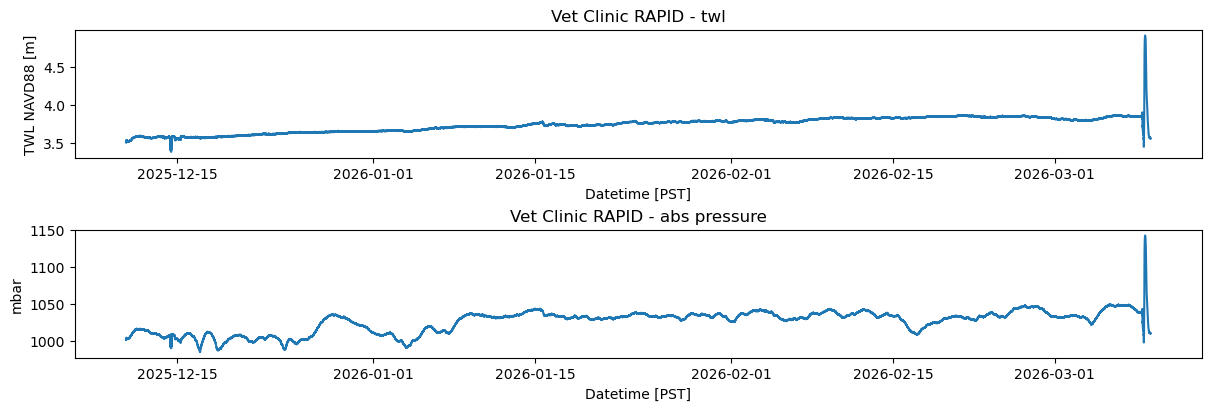

In [289]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(vet_dt, vet_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("Vet Clinic RAPID - twl")


ax[1].plot(vet_dt, vet_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("Vet Clinic RAPID - abs pressure");

**Waterstreet**

In [275]:
waterstreet_df = pd.read_csv(waterstreet_file)
waterstreet_serial_num = 17
waterstreet_navd88_offset = 3.559 # meters REVISIT
waterstreet_df["Datetime[PST]"] = pd.to_datetime(waterstreet_df["W.G. Num: 17"].astype(str) + " " + waterstreet_df["Timestamp"].astype(str),
                                              format="%Y/%m/%d %H:%M:%S:%f", errors="coerce")

vet_df.head()

,W.G. Num: 44,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:35:16:131,1001.8,23.91,4.23,2025-12-10 13:35:16.131,101597.916667,997.760779,100180.0,-0.144862,3.505138
1,2025/12/10,13:37:17:030,1002.0,23.90,4.16,2025-12-10 13:37:17.030,101597.500000,997.763237,100200.0,-0.142776,3.507224
2,2025/12/10,13:39:17:030,1002.2,23.88,4.16,2025-12-10 13:39:17.030,101597.083333,997.768149,100220.0,-0.140689,3.509311
3,2025/12/10,13:41:17:030,1002.1,23.87,4.16,2025-12-10 13:41:17.030,101596.111111,997.770604,100210.0,-0.141611,3.508389
4,2025/12/10,13:43:17:030,1002.0,23.85,4.16,2025-12-10 13:43:17.030,101595.555556,997.775510,100200.0,-0.142576,3.507424


In [277]:
waterstreet_start = waterstreet_df["Datetime[PST]"].dropna().iloc[0]
waterstreet_end   = waterstreet_df["Datetime[PST]"].dropna().iloc[-1]
waterstreet_met_df_5min = fetch_noaa_met_data(waterstreet_start, waterstreet_end)
waterstreet_df["MetPressure[Pa]"] = itp_noaa_metdata(waterstreet_met_df_5min, waterstreet_df["Datetime[PST]"]).values
g = 9.81
salinity = 0.5
waterstreet_df["Rho[kg/m^3]"]    = density(waterstreet_df["Temp [deg C]"], salinity)
waterstreet_df["AbsPressure[Pa]"] = waterstreet_df["Pressure [mbar]"] * 100
waterstreet_df["TWL[m]"]          = (waterstreet_df["AbsPressure[Pa]"] - waterstreet_df["MetPressure[Pa]"]) / (waterstreet_df["Rho[kg/m^3]"] * g)
waterstreet_df["TWLNAVD88[m]"]    = waterstreet_df["TWL[m]"] + waterstreet_navd88_offset
waterstreet_dt  = waterstreet_df["Datetime[PST]"]
waterstreet_twl = waterstreet_df["TWLNAVD88[m]"]
waterstreet_df.head()

Fetching 3 chunk(s) from NOAA CO-OPS...
  Chunk 1/3: 2025-12-10 → 2026-01-10 (7440 records)
  Chunk 2/3: 2026-01-10 → 2026-02-10 (7440 records)
  Chunk 3/3: 2026-02-10 → 2026-03-09 (6477 records)


,W.G. Num: 17,Timestamp,Pressure [mbar],Temp [deg C],Battery [VDC],Datetime[PST],MetPressure[Pa],Rho[kg/m^3],AbsPressure[Pa],TWL[m],TWLNAVD88[m]
0,2025/12/10,13:27:49:133,996.8,23.67,4.27,2025-12-10 13:27:49.133,101602.222222,997.819493,99680.0,-0.196373,3.362627
1,2025/12/10,13:29:49:030,996.8,23.68,4.14,2025-12-10 13:29:49.030,101601.111111,997.817058,99680.0,-0.196260,3.362740
2,2025/12/10,13:31:49:030,996.7,23.69,4.14,2025-12-10 13:31:49.030,101599.444444,997.814621,99670.0,-0.197112,3.361888
3,2025/12/10,13:33:49:030,996.5,23.70,4.14,2025-12-10 13:33:49.030,101598.888889,997.812184,99650.0,-0.199099,3.359901
4,2025/12/10,13:35:49:030,996.5,23.70,4.14,2025-12-10 13:35:49.030,101597.916667,997.812184,99650.0,-0.199000,3.360000


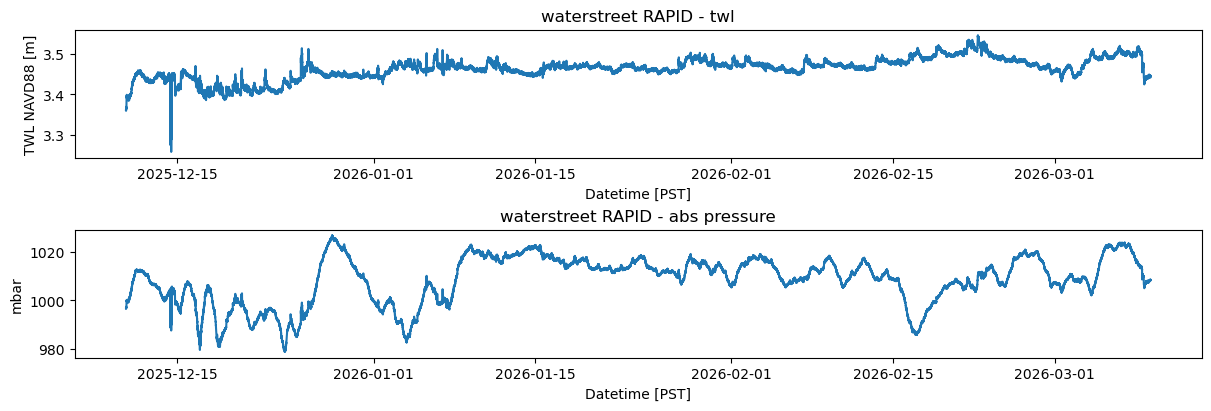

In [291]:
fig, ax = plt.subplots(2, 1, figsize=(12,4), layout="constrained")

ax[0].plot(waterstreet_dt, waterstreet_twl)
ax[0].set_xlabel("Datetime [PST]")
ax[0].set_ylabel("TWL NAVD88 [m]")
ax[0].set_title("waterstreet RAPID - twl")


ax[1].plot(waterstreet_dt, waterstreet_df["Pressure [mbar]"])
ax[1].set_xlabel("Datetime [PST]")
ax[1].set_ylabel("mbar")
ax[1].set_title("waterstreet RAPID - abs pressure");

## RIVER SENSORS

**TP** (NOT UPDATED)

In [ ]:
# ### NOAA nov+dec+jan

# TPnov_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPnov.csv"
# TPdec_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPdec.csv"
# TPjan_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/TPjan.csv"

# TPnov_df = pd.read_csv(TPnov_file)
# TPdec_df = pd.read_csv(TPdec_file)
# TPjan_df = pd.read_csv(TPjan_file)

# TP_df = pd.concat([TPnov_df, TPdec_df, TPjan_df], ignore_index=True) # LST time and metric

# TP_df['DateTime'] = pd.to_datetime(TP_df['Date'] + ' ' + TP_df['Time (LST/LDT)'])
# TP_df['Verified (m)'] = pd.to_numeric(TP_df['Verified (m)'], errors='coerce')

# TP_dt = TP_df["DateTime"]
# TP_twl = TP_df["Verified (m)"]

# TP_df.head()

In [ ]:
# plt.plot(TP_dt, TP_twl)

**WR01** (NOT UPDATED)

In [ ]:
# wr01_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Bendiksen_nov11tojan31.xlsx"
# wr01_df = pd.read_excel(wr01_file, skiprows=1)

# # data cleaning
# wr01_df["SWE NAVD88 (m)"] = (wr01_df["Level/Stage (ft)"] * 0.3048) - 0.427  # in m NAVD88
# wr01_df['Date&Time'] = pd.to_datetime(wr01_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
# wr01_df = wr01_df.sort_values('Date&Time').reset_index(drop=True)

# wr01_df = wr01_df.iloc[100:].reset_index(drop=True)
# wr01_df = wr01_df.set_index('Date&Time')
# wr01_df = wr01_df.asfreq('5min')
# wr01_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan

# wr01_dt = wr01_df.index
# wr01_twl = wr01_df["SWE NAVD88 (m)"]

# wr01_df.head()

In [ ]:
# plt.plot(wr01_dt, wr01_twl)

**WR02** (NOT UPDATED)

In [ ]:
# wr02_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Raymond_nov7tojan31.xlsx"
# wr02_df = pd.read_excel(wr02_file, skiprows=1)

# # data cleaning
# wr02_df["SWE NAVD88 (m)"] = (wr02_df["Level/Stage (ft)"] * 0.3048) - 0.427
# wr02_df['Date&Time'] = pd.to_datetime(wr02_df["Date&Time"], format="%m/%d/%Y %I:%M:%S %p")
# wr02_df = wr02_df.sort_values('Date&Time').reset_index(drop=True)

# # wr02_df = wr02_df.iloc[100:].reset_index(drop=True)
# wr02_df = wr02_df.set_index('Date&Time')
# wr02_df = wr02_df.asfreq('5min')
# wr02_df.loc['2025-12-05 08:55:00':'2025-12-06 15:10:00', 'SWE NAVD88 (m)'] = np.nan

# wr02_dt = wr02_df.index
# wr02_twl = wr02_df["SWE NAVD88 (m)"]

# wr02_df.head()

In [ ]:
# plt.plot(wr02_dt, wr02_twl)

**WR03** (need to fix NAVD88 offset)

In [ ]:
wr03_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR03_260308201320_FS029.CSV"
wr03_df = pd.read_csv(wr03_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

# data cleaning
wr03_df = wr03_df.iloc[24:].reset_index(drop=True)
wr03_df.loc[11028:11036, 'Pressure[cmH2O]'] = np.nan
wr03_df['Pressure[cmH2O]'] = wr03_df['Pressure[cmH2O]'].interpolate(method='linear')
wr03_df['Pressure[ftH2O]'] = wr03_df['Pressure[cmH2O]'] * 0.0328084  # convert cmH2O to ftH2O
wr03_df['Date/time'] = pd.to_datetime(wr03_df['Date/time'])
wr03_df['DateTime_PST'] = wr03_df['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

# Fetch NOAA met data over sensor timespan
sensor_start = wr03_df["DateTime_PST"].iloc[0]
sensor_end   = wr03_df["DateTime_PST"].iloc[-1]
met_df_5min  = fetch_noaa_met_data(sensor_start, sensor_end)

# Pressure and density calculations
g = 9.81  # m/s^2
salinity = 0.5  # PSU approx based on CTD data
wr03_df["Rho[kg/m^3]"] = density(wr03_df["Temperature[°C]"], salinity)
wr03_df["AbsPressure[Pa]"] = ftH2O_to_Pa(wr03_df["Pressure[ftH2O]"], wr03_df["Temperature[°C]"], salinity)

# Interpolate met pressure to sensor timestamps and compute TWL
wr03_df["MetPressure[Pa]"] = met_df_5min.reindex(met_df_5min.index.union(wr03_df["DateTime_PST"])).interpolate(method="linear").reindex(wr03_df["DateTime_PST"].values).values

wr03_df["TWL[m]"] = (wr03_df["AbsPressure[Pa]"] - wr03_df["MetPressure[Pa]"]) / (wr03_df["Rho[kg/m^3]"] * g)
wr03_df["TWL[m]"] = np.where(wr03_df["TWL[m]"] < 0, np.nan, wr03_df["TWL[m]"])
wr03_df["TWLNAVD88[m]"] = wr03_df["TWL[m]"] - 1.108

wr03_dt  = wr03_df["DateTime_PST"]
wr03_twl = wr03_df["TWLNAVD88[m]"]
wr03_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(wr03_dt, wr03_twl)
ax.set_title("WR03 D5");

**WR04**

In [ ]:
wr04_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/FIELD/D5 retrieval/WR04_260308201401_FS064.CSV"
wr04_df = pd.read_csv(wr04_file, encoding='latin-1', skiprows=51, skipfooter=1, engine='python')

# data cleaning
wr04_df['Pressure[cmH2O]'] = wr04_df['Pressure[cmH2O]'].interpolate(method='linear')
wr04_df['Pressure[ftH2O]'] = wr04_df['Pressure[cmH2O]'] * 0.0328084  # convert cmH2O to ftH2O
wr04_df['Date/time'] = pd.to_datetime(wr04_df['Date/time'])
wr04_df['DateTime_PST'] = wr04_df['Date/time'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

# Fetch NOAA met data over sensor timespan
sensor_start = wr04_df["DateTime_PST"].iloc[0]
sensor_end   = wr04_df["DateTime_PST"].iloc[-1]
met_df_5min  = fetch_noaa_met_data(sensor_start, sensor_end)

# Pressure and density calculations
g = 9.81  # m/s^2
salinity = 0.5  # PSU approx based on CTD data
wr04_df["Rho[kg/m^3]"] = density(wr04_df["Temperature[°C]"], salinity)
wr04_df["AbsPressure[Pa]"] = ftH2O_to_Pa(wr04_df["Pressure[ftH2O]"], wr04_df["Temperature[°C]"], salinity)

# Interpolate met pressure to sensor timestamps and compute TWL
wr04_df["MetPressure[Pa]"] = met_df_5min.reindex(met_df_5min.index.union(wr04_df["DateTime_PST"])).interpolate(method="linear").reindex(wr04_df["DateTime_PST"].values).values

wr04_df["TWL[m]"] = (wr04_df["AbsPressure[Pa]"] - wr04_df["MetPressure[Pa]"]) / (wr04_df["Rho[kg/m^3]"] * g)
wr04_df["TWL[m]"] = np.where(wr04_df["TWL[m]"] < 0, np.nan, wr04_df["TWL[m]"])
wr04_df["TWLNAVD88[m]"] = wr04_df["TWL[m]"] - 1.108

wr04_dt  = wr04_df["DateTime_PST"]
wr04_twl = wr04_df["TWLNAVD88[m]"]
wr04_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(wr04_dt, wr04_twl)
ax.set_title("WR04 D5");

**WR06** (take the brackish one and then add the other txt and concatenate)

In [ ]:
wr06is_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/InSitu632743brackish_2026-01-11_13-47-47-563.csv"
wr06is_df = pd.read_csv(wr06is_file, skiprows=70)
wr06is_df.columns = wr06is_df.columns.str.rstrip()
wr06is_df['datetime'] = pd.to_datetime(wr06is_df['Date and Time'].str.strip(" '"), format='%m/%d/%Y %I:%M:%S %p')

# Create Time shift column - subtract 15 hours
wr06is_df['Time shift'] = wr06is_df['datetime'] - pd.Timedelta(hours=15)

# Fetch NOAA met data over sensor timespan
sensor_start = wr06is_df["datetime"].iloc[0]
sensor_end   = wr06is_df["datetime"].iloc[-1]
met_df_5min  = fetch_noaa_met_data(sensor_start, sensor_end)

# Pressure and density calculations
g = 9.81
salinity = 0  # PSU approx based on CTD data
wr06is_df["Temperature (C)"] = (wr06is_df["Temperature (F)"] - 32) * (5/9)
wr06is_df["Rho[kg/m^3]"] = density(wr06is_df["Temperature (C)"], salinity)
wr06is_df["Press_Pa"] = wr06is_df["Pressure (PSI)"] * 6894.76  # convert to Pa

# Interpolate met pressure to sensor timestamps and compute TWL
wr06is_df["MetPressure[Pa]"] = met_df_5min.reindex(
    met_df_5min.index.union(wr06is_df["datetime"])
).interpolate(method="linear").reindex(wr06is_df["datetime"].values).values

wr06is_df["TWL[m]"] = (wr06is_df["Press_Pa"] - wr06is_df["MetPressure[Pa]"]) / (wr06is_df["Rho[kg/m^3]"] * g)
wr06is_df["TWL[m]"] = np.where(wr06is_df["TWL[m]"] < 0, np.nan, wr06is_df["TWL[m]"])
wr06is_df["TWLNAVD88[m]"] = wr06is_df["TWL[m]"] - 1.091  # meters THIS IS AN ESTIMATE

wr06is_dt = wr06is_df["Time shift"]
wr06is_twl = wr06is_df["TWLNAVD88[m]"]
# wr06is_dt_trim = wr06is_dt.iloc[274:8287]
# wr06is_twl_trim = wr06is_twl.iloc[274:8287]
wr06is_df.head()

print(wr06is_df["Depth (ft)"].describe())
print(wr06is_df["Depth (ft)"].iloc[274:8287].describe())

In [ ]:
# wr06is_df_trim.plot(x=index, y='TWLNAVD88[m]')
plt.figure(figsize=(15, 5))
plt.plot(wr06is_dt, wr06is_twl)

In [ ]:
# CTD 11/6 - 12/15

wr06ctd_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/Copy of CTD_WR06_12.14retrieval.txt"
wr06ctd_df = pd.read_csv(wr06ctd_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr06ctd_df.columns = wr06ctd_df.columns.str.strip()
wr06ctd_df = wr06ctd_df[~wr06ctd_df['Date'].str.contains('-', na=False)]
wr06ctd_df['DateTime'] = pd.to_datetime(wr06ctd_df['Date'] + ' ' + wr06ctd_df['Time'])

# Convert UTC to PST (UTC-8) and remove timezone info
wr06ctd_df['DateTime_PST'] = wr06ctd_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr06ctd_df = wr06ctd_df.reset_index(drop=True)
wr06ctd_df["Press"] = pd.to_numeric(wr06ctd_df["Press"], errors='coerce')
wr06ctd_df = wr06ctd_df.reset_index(drop=True)
wr06ctd_df["Press_Pa"] = wr06ctd_df["Press"] * 6894.76

wr06ctd_df["Temp"] = pd.to_numeric(wr06ctd_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr06ctd_df["Rho[kg/m^3]"] = density(wr06ctd_df["Temp"], salinity)
g = 9.81

wr06ctd_itp_metp = itp_noaa_metdata(met_df_5min, wr06ctd_df["DateTime_PST"])
wr06ctd_df["MetPressure[Pa]"] = wr06ctd_itp_metp.values
wr06ctd_df["TWL[m]"] = (wr06ctd_df["Press_Pa"] - wr06ctd_df["MetPressure[Pa]"]) / (wr06ctd_df["Rho[kg/m^3]"] * g)
wr06ctd_df["TWL[m]"] = np.where(wr06ctd_df["TWL[m]"] < 0, np.nan, wr06ctd_df["TWL[m]"])
wr06ctd_df["TWLNAVD88[m]"] = wr06ctd_df["TWL[m]"] - 0.238  # meters

wr06ctd_dt = wr06ctd_df["DateTime_PST"]
wr06ctd_twl= wr06ctd_df["TWLNAVD88[m]"]

wr06ctd_dt_trim = wr06ctd_dt.iloc[20:11068] 
wr06ctd_twl_trim = wr06ctd_twl.iloc[20:11068] - 0.75 # after overlaying wr04 to fix it

wr06ctd_df.tail()

In [ ]:
plt.figure(figsize=(15, 5))
# plt.plot(wr04_dt, wr04_twl, color="black")
plt.plot(wr06is_dt_trim, wr06is_twl_trim)
plt.plot(wr06ctd_dt_trim, wr06ctd_twl_trim)


**WR07**

In [ ]:
wr07ctd_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/WR07_CTD.txt"
wr07ctd_df = pd.read_csv(wr07ctd_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr07ctd_df.columns = wr07ctd_df.columns.str.strip()
wr07ctd_df = wr07ctd_df[~wr07ctd_df['Date'].str.contains('-', na=False)]
wr07ctd_df['DateTime'] = pd.to_datetime(wr07ctd_df['Date'] + ' ' + wr07ctd_df['Time'])
wr07ctd_df = wr07ctd_df.reset_index(drop=True)
wr07ctd_df["Press"] = pd.to_numeric(wr07ctd_df["Press"], errors='coerce')
wr07ctd_df = wr07ctd_df.iloc[27:13910]
wr07ctd_df = wr07ctd_df.reset_index(drop=True)
wr07ctd_df["Press_Pa"] = wr07ctd_df["Press"] * 6894.76

wr07ctd_df['DateTime'] = pd.to_datetime(wr07ctd_df['DateTime'])
wr07ctd_df['DateTime_PST'] = wr07ctd_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)

wr07ctd_df["Temp"] = pd.to_numeric(wr07ctd_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr07ctd_df["Rho[kg/m^3]"] = density(wr07ctd_df["Temp"], salinity)

g = 9.81

wr07ctd_itp_metp = itp_noaa_metdata(met_df_5min, wr07ctd_df["DateTime"])
wr07ctd_df["MetPressure[Pa]"] = wr07ctd_itp_metp.values

wr07ctd_df["TWL[m]"] = (wr07ctd_df["Press_Pa"] - wr07ctd_df["MetPressure[Pa]"]) / (wr07ctd_df["Rho[kg/m^3]"] * g)
wr07ctd_df["TWL[m]"] = np.where(wr07ctd_df["TWL[m]"] < 0, np.nan, wr07ctd_df["TWL[m]"])

wr07ctd_df["TWLNAVD88[m]"] = wr07ctd_df["TWL[m]"] + 0.124 # meters

wr07_dt = wr07ctd_df["DateTime_PST"]
wr07_twl= wr07ctd_df["TWLNAVD88[m]"]

wr07_dt_trim = wr07_dt[:13850]
wr07_twl_trim = wr07_twl[:13850]

wr07ctd_df.head()

In [ ]:
plt.plot(wr07_dt_trim, wr07_twl_trim)

**WR08**

In [ ]:
# CTD2004_WR08_012826.txt

wr08_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/CTD2004_WR08_012826.txt"
wr08_df = pd.read_csv(wr08_file, sep=',', skiprows=[0, 2], header=0)

# data cleaning
wr08_df.columns = wr08_df.columns.str.strip()
wr08_df = wr08_df[~wr08_df['Date'].str.contains('-', na=False)]
wr08_df['DateTime'] = pd.to_datetime(wr08_df['Date'] + ' ' + wr08_df['Time'])
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["Press"] = pd.to_numeric(wr08_df["Press"], errors='coerce')
# wr06ctd_df = wr06ctd_df.iloc[27:13910] WHAT ABOUT THIS
wr08_df = wr08_df.reset_index(drop=True)
wr08_df["Press_Pa"] = wr08_df["Press"] * 6894.76

wr08_df['DateTime'] = pd.to_datetime(wr08_df['DateTime'])
wr08_df['DateTime_PST'] = wr08_df['DateTime'].dt.tz_localize('UTC').dt.tz_convert('US/Pacific').dt.tz_localize(None)


wr08_df["Temp"] = pd.to_numeric(wr08_df["Temp"], errors='coerce')

salinity = 0 # PSU approx based on CTD data
wr08_df["Rho[kg/m^3]"] = density(wr08_df["Temp"], salinity)

g = 9.81

wr08_itp_metp = itp_noaa_metdata(met_df_5min, wr08_df["DateTime"])
wr08_df["MetPressure[Pa]"] = wr08_itp_metp.values

wr08_df["TWL[m]"] = (wr08_df["Press_Pa"] - wr08_df["MetPressure[Pa]"]) / (wr08_df["Rho[kg/m^3]"] * g)
wr08_df["TWL[m]"] = np.where(wr08_df["TWL[m]"] < 0, np.nan, wr08_df["TWL[m]"])

wr08_df["TWLNAVD88[m]"] = wr08_df["TWL[m]"] - 0 # OFFSET UNKNOWN...

wr08_dt = wr08_df["DateTime_PST"]
wr08_twl= wr08_df["TWLNAVD88[m]"]

wr08_dt_trim = wr08_dt[46:18496]
wr08_twl_trim = wr08_twl[46:18496]

wr08_df.tail()

In [ ]:
plt.figure(figsize=(12,3))
plt.plot(wr08_dt_trim, wr08_twl_trim)

**USGS**

In [ ]:
# waterservices.usgs.gov.txt

usgs_file = "/Users/sashabugbee/Downloads/Grays Harbor and Willapa Bay/Signal Deconstruction/wriverusgs.txt"
usgs_df = pd.read_csv(usgs_file, sep='\t', skiprows=list(range(26)) + [27], header=0)

usgs_df["gage h (m)"] = mont_df["150645_00065"] * 0.3048

usgs_dt = usgs_df["datetime"]
usgs_twl = usgs_df["gage h (m)"]


usgs_df.head()

In [ ]:
plt.plot(usgs_dt, usgs_twl)

## Timeseries Plot

In [ ]:
fig, ax = plt.subplots(9, 1, figsize=(8, 13), sharex=True)

# Define date range
plot_start = pd.to_datetime('2025-12-01')
plot_end = pd.to_datetime('2025-12-24')

# Convert to datetime and create masks for filtering
usgs_dt = pd.to_datetime(usgs_dt, errors='coerce')
usgs_mask = (usgs_dt >= plot_start) & (usgs_dt <= plot_end)

wr08_dt_trim = pd.to_datetime(wr08_dt_trim, errors='coerce')
wr08_mask = (wr08_dt_trim >= plot_start) & (wr08_dt_trim <= plot_end)

wr07_dt_trim = pd.to_datetime(wr07_dt_trim, errors='coerce')
wr07_mask = (wr07_dt_trim >= plot_start) & (wr07_dt_trim <= plot_end)

wr06is_dt_trim = pd.to_datetime(wr06is_dt_trim, errors='coerce')
wr06is_mask = (wr06is_dt_trim >= plot_start) & (wr06is_dt_trim <= plot_end)

wr06ctd_dt_trim = pd.to_datetime(wr06ctd_dt_trim, errors='coerce')
wr06ctd_mask = (wr06ctd_dt_trim >= plot_start) & (wr06ctd_dt_trim <= plot_end)

wr04_dt = pd.to_datetime(wr04_dt, errors='coerce')
wr04_mask = (wr04_dt >= plot_start) & (wr04_dt <= plot_end)

wr03_dt = pd.to_datetime(wr03_dt, errors='coerce')
wr03_mask = (wr03_dt >= plot_start) & (wr03_dt <= plot_end)

wr02_dt = pd.to_datetime(wr02_dt, errors='coerce')
wr02_mask = (wr02_dt >= plot_start) & (wr02_dt <= plot_end)

wr01_dt = pd.to_datetime(wr01_dt, errors='coerce')
wr01_mask = (wr01_dt >= plot_start) & (wr01_dt <= plot_end)

TP_dt = pd.to_datetime(TP_dt, errors='coerce')
TP_mask = (TP_dt >= plot_start) & (TP_dt <= plot_end)

# Plot each dataset on separate panels with color gradient
ax[0].plot(mont_dt[mont_mask], mont_twl[mont_mask]*3.28084, color='darkgreen', label='Willapa River USGS')
ax[0].legend(loc='upper right')
ax[0].grid()

ax[1].plot(wr08_dt_trim[wr08_mask], wr08_twl_trim[wr08_mask]*3.28084, color='forestgreen', label='WR08')
ax[1].legend(loc='upper right')
ax[1].grid()
ax[1].set_ylim([-5, 22])

ax[2].plot(wr07_dt_trim[wr07_mask], wr07_twl_trim[wr07_mask]*3.28084, color='darkcyan', label='WR07')
ax[2].legend(loc='upper right')
ax[2].grid()
ax[2].set_ylim([-5, 22])

# WR06 IS and CTD on same panel with same color
ax[3].plot(wr06is_dt_trim[wr06is_mask], wr06is_twl_trim[wr06is_mask]*3.28084, color='steelblue', label='WR06')
ax[3].plot(wr06ctd_dt_trim[wr06ctd_mask], wr06ctd_twl_trim[wr06ctd_mask]*3.28084, color='steelblue')
ax[3].legend(loc='upper right')
ax[3].grid()
ax[3].set_ylim([-5, 22]) # steelblue royalblue mediumblue

ax[4].plot(wr04_dt[wr04_mask], wr04_twl[wr04_mask]*3.28084, color='royalblue', label='WR04')
ax[4].set_ylabel('Water Level [ft] NAVD88')  # Only y-axis label
ax[4].legend(loc='upper right')
ax[4].grid()
ax[4].set_ylim([-5, 22])

ax[5].plot(wr03_dt[wr03_mask], wr03_twl[wr03_mask]*3.28084, color='mediumblue', label='WR03')
ax[5].legend(loc='upper right')
ax[5].grid()
ax[5].set_ylim([-5, 22])

ax[6].plot(wr02_dt[wr02_mask], wr02_twl[wr02_mask]*3.28084, color='slateblue', label='WR02')
ax[6].legend(loc='upper right')
ax[6].grid()
ax[6].set_ylim([-5, 22])

ax[7].plot(wr01_dt[wr01_mask], wr01_twl[wr01_mask]*3.28084, color='rebeccapurple', label='WR01')
ax[7].legend(loc='upper right')
ax[7].grid()
ax[7].set_ylim([-5, 22])

ax[8].plot(TP_dt[TP_mask], TP_twl[TP_mask]*3.28084, color='indigo', label='Toke Point NOAA')
ax[8].set_xlabel('DateTime (PST)')
ax[8].legend(loc='upper right')
ax[8].grid()
ax[8].set_ylim([-5, 22])

# Set x-axis limits for all panels
for i in ax:
    i.set_xlim([plot_start, plot_end])

fig.suptitle("Along-channel evolution of compound flooding")

shade_start = pd.Timestamp('2025-12-08')
shade_end = pd.Timestamp('2025-12-13')

for ax in ax:
    ax.axvspan(shade_start, shade_end, alpha=0.3, color='lightgrey', zorder=0)

fig.tight_layout()
plt.show()